# Analisis exploratorio del tiempo de entrega

**TFM SmartDeliveryAI** — prediccion de la hora de llegada de un paquete.

Este notebook es la version narrativa del EDA. El script `EDA Tiempos.py` hace el mismo analisis
de forma reproducible y genera las figuras y el informe de hallazgos; aqui se explica el
razonamiento paso a paso.

## Que se quiere predecir

```text
travel_time_seconds     el tiempo en ir de una parada a la siguiente
```

Se predice **por tramo**. La hora de llegada a cualquier parada sale de sumar los tramos
anteriores mas los tiempos de entrega previos, y anadirlo a la hora de salida del almacen.

## Indice

**Parte A: la tabla de tramos** (la que alimenta el modelo)

1. Preparacion y carga
2. Vision general y tipos
3. Calidad: nulos, duplicados, constantes
4. La variable objetivo
5. Univariante: numericas y categoricas
6. Valores atipicos
7. Correlaciones y multicolinealidad
8. Distancia frente a tiempo
9. Baselines de referencia
10. Que explica el residuo
11. Contexto: geografia, tiempo y clima
12. Contrastes estadisticos

**Parte B: la tabla de rutas** (contexto y planificacion)

13. Calidad y columnas equivalentes
14. Como es una ruta tipica
15. Que determina su duracion

**Cierre**

16. Conclusiones para el modelado

## 1. Preparacion y carga

Spark necesita Java. Las rutas se detectan segun el sistema operativo para que el notebook funcione igual en Windows y en macOS.

In [ ]:
import os
import platform
import tempfile
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "gold").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Raiz del proyecto:", PROJECT_ROOT)


def detect_java_home():
    if os.environ.get("JAVA_HOME"):
        return os.environ["JAVA_HOME"]
    if platform.system() == "Windows":
        local = PROJECT_ROOT / ".jdk"
        base = Path("C:/Program Files/Eclipse Adoptium")
        cand = sorted(local.glob("jdk-17*"), reverse=True) if local.exists() else []
        cand += sorted(base.glob("jdk-17*"), reverse=True) if base.exists() else []
    else:
        cand = [Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home")]
    return next((str(c) for c in cand if c.exists()), None)


java_home = detect_java_home()
if java_home:
    os.environ["JAVA_HOME"] = java_home
    os.environ["PATH"] = f"{java_home}{os.sep}bin{os.pathsep}{os.environ.get('PATH', '')}"
if platform.system() == "Windows":
    os.environ.setdefault("HADOOP_HOME", str(PROJECT_ROOT / ".hadoop"))
    os.environ["PATH"] = f"{os.environ['HADOOP_HOME']}{os.sep}bin{os.pathsep}{os.environ.get('PATH', '')}"
print("JAVA_HOME:", java_home)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.size": 9})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

OBJETIVO = "travel_time_seconds"
AZUL, ROJO, NARANJA, VERDE = "#4F81A6", "#C0504D", "#E8A33D", "#6E9E52"
NO_PREDICTORAS = {"route_id", "from_stop_id", "to_stop_id", "from_lat", "from_lng", "to_lat", "to_lng"}


def r2(y, pred):
    return 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()


def numericas(df):
    return [c for c in df.select_dtypes(include=[np.number]).columns if c not in NO_PREDICTORAS]

Se abre Gold con PySpark, que es el motor del proyecto, y se pasa a pandas para graficar. Si el volumen creciera, aqui se haria un muestreo o una agregacion en Spark antes de bajar los datos.

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("SmartDeliveryAI EDA notebook")
    .master("local[*]")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.local.dir", str(Path(tempfile.gettempdir()) / "smartdeliveryai_spark_local"))
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

gold = PROJECT_ROOT / "data" / "gold"
tramos = spark.read.parquet(str(gold / "Dataset Tramos Ruta" / "Dataset Tramos Ruta.parquet")).toPandas()
rutas = spark.read.parquet(str(gold / "Dataset Rutas Enriquecidas" / "Dataset Rutas Enriquecidas.parquet")).toPandas()
spark.stop()

print(f"{len(tramos):,} tramos x {tramos.shape[1]} columnas")
print(f"{len(rutas):,} rutas x {rutas.shape[1]} columnas")
tramos.head(3)

# Parte A: la tabla de tramos

## 2. Vision general

In [4]:
print("Periodo:", tramos.route_date.min(), "a", tramos.route_date.max())
print("Estaciones:", tramos.station_code.nunique())
print("Memoria:", round(tramos.memory_usage(deep=True).sum() / 1e6, 1), "MB")
print()
tramos.dtypes.value_counts().to_frame("columnas")

Periodo: 2018-07-19 a 2018-08-26
Estaciones: 17


Memoria: 285.1 MB



,columnas
float64,14
int32,7
str,6
int64,3
object,1


## 3. Calidad de los datos

Gold viene de un pipeline con validaciones, asi que lo esperable es que no haya sorpresas. Lo
interesante es detectar columnas que no aportan informacion.

In [5]:
print("Celdas nulas:", tramos.isna().sum().sum())
print("Filas duplicadas:", tramos.duplicated().sum())
print("Duplicados por clave (ruta + posicion):", tramos.duplicated(["route_id", "segment_position"]).sum())
print()
nulos = tramos.isna().sum()
nulos[nulos > 0].to_frame("nulos")

Celdas nulas: 37744


Filas duplicadas: 0
Duplicados por clave (ruta + posicion): 0



,nulos
from_zone_id,12529
to_zone_id,6515
same_zone,18700


Los nulos se concentran en las variables de zona, y tienen explicacion: **el almacen no
pertenece a ninguna zona de reparto**, asi que en el tramo que sale de el no hay zona de origen
ni se puede comparar con la de destino.

Comprobamos que no haya columnas constantes ni valores imposibles.

In [6]:
constantes = [c for c in tramos.columns if tramos[c].nunique(dropna=False) <= 1]
print("Columnas constantes:", constantes or "ninguna")

num = numericas(tramos)
negativos = {c: int((tramos[c] < 0).sum()) for c in num if (tramos[c] < 0).any()}
print("Columnas con valores negativos:", negativos or "ninguna")

Columnas constantes: ninguna
Columnas con valores negativos: ninguna


## 4. La variable objetivo

Aqui esta el hallazgo que mas condiciona todo el modelado.

In [7]:
dep = tramos[tramos.is_depot_segment == 1][OBJETIVO]
rep = tramos[tramos.is_depot_segment == 0][OBJETIVO]

resumen = pd.DataFrame({
    "tramos": [len(rep), len(dep)],
    "media_min": [rep.mean() / 60, dep.mean() / 60],
    "mediana_min": [rep.median() / 60, dep.median() / 60],
    "p95_min": [rep.quantile(.95) / 60, dep.quantile(.95) / 60],
    "max_min": [rep.max() / 60, dep.max() / 60],
    "asimetria": [rep.skew(), dep.skew()],
}, index=["reparto", "almacen -> zona"]).round(2)
resumen

,tramos,media_min,mediana_min,p95_min,max_min,asimetria
reparto,892303,1.02,0.76,2.83,39.12,3.60
almacen -> zona,6112,30.19,29.91,48.54,95.85,0.33


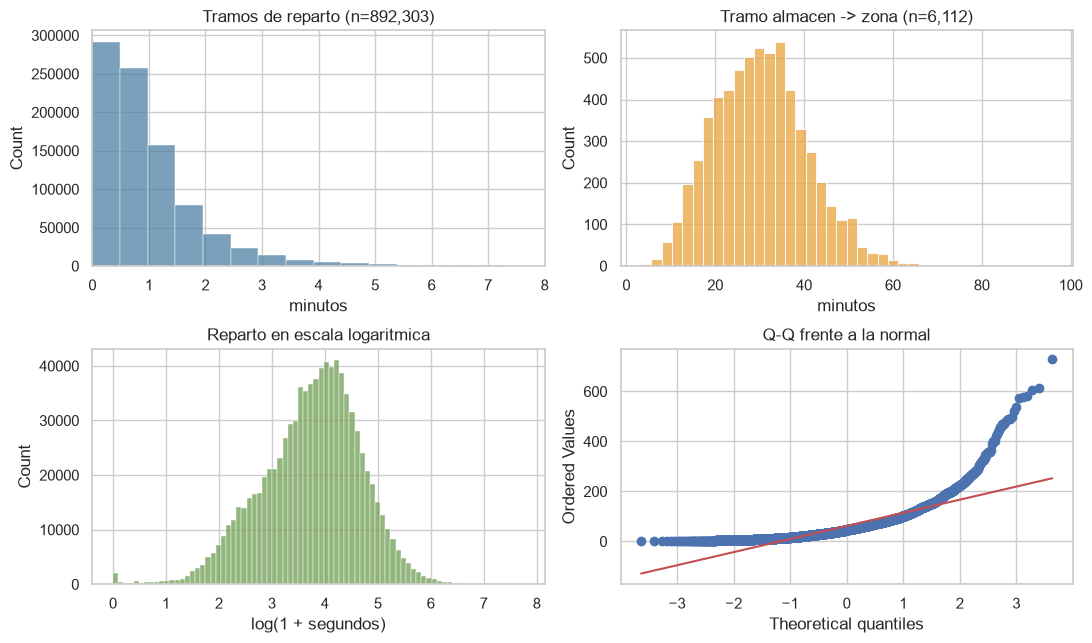

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
sns.histplot(rep / 60, bins=80, color=AZUL, ax=axes[0, 0])
axes[0, 0].set_xlim(0, 8); axes[0, 0].set_title(f"Tramos de reparto (n={len(rep):,})"); axes[0, 0].set_xlabel("minutos")
sns.histplot(dep / 60, bins=40, color=NARANJA, ax=axes[0, 1])
axes[0, 1].set_title(f"Tramo almacen -> zona (n={len(dep):,})"); axes[0, 1].set_xlabel("minutos")
sns.histplot(np.log1p(rep), bins=80, color=VERDE, ax=axes[1, 0])
axes[1, 0].set_title("Reparto en escala logaritmica"); axes[1, 0].set_xlabel("log(1 + segundos)")
stats.probplot(rep.sample(5000, random_state=42), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q frente a la normal")
plt.tight_layout(); plt.show()

**El objetivo son dos poblaciones, no una.** El tramo que sale del almacen dura unos 30
minutos y los saltos entre entregas apenas 1: casi **30 veces mas**. Es un viaje por carretera
hasta el barrio frente a saltos de portal a portal.

Consecuencia directa: un modelo unico que no las distinga intenta servir a dos realidades
incompatibles. Hay que incluir `is_depot_segment` o entrenar por separado.

Ademas la distribucion del reparto esta muy sesgada a la derecha. El grafico Q-Q se separa
claramente de la recta, y aplicando logaritmo la forma mejora bastante. Eso importa al elegir
modelo: los lineales sufren con esta asimetria, los de arboles no.

In [9]:
muestra = rep.sample(5000, random_state=42)
print("Shapiro-Wilk sobre el original: p =", f"{stats.shapiro(muestra).pvalue:.3g}")
print("Shapiro-Wilk sobre el logaritmo: p =", f"{stats.shapiro(np.log1p(muestra)).pvalue:.3g}")
print()
print("Asimetria original:", round(rep.skew(), 3))
print("Asimetria tras log:", round(np.log1p(rep).skew(), 3))

Shapiro-Wilk sobre el original: p = 8.9e-67
Shapiro-Wilk sobre el logaritmo: p = 3.08e-18

Asimetria original: 3.597
Asimetria tras log: -0.461


## 5. Univariante

### Variables numericas

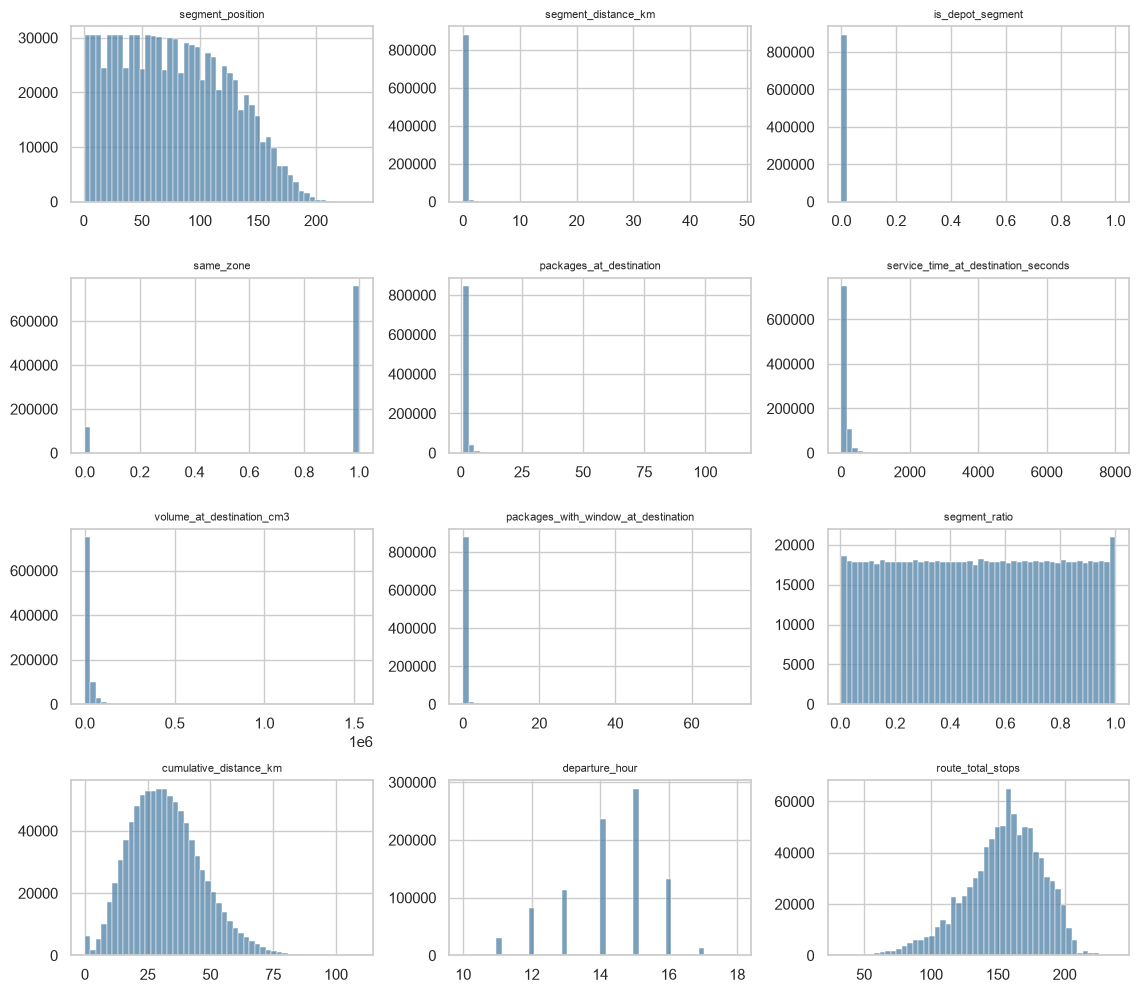

In [10]:
cols = [c for c in numericas(tramos) if c != OBJETIVO][:12]
fig, axes = plt.subplots(4, 3, figsize=(11.5, 10))
for ax, c in zip(axes.flat, cols):
    sns.histplot(tramos[c], bins=50, color=AZUL, ax=ax)
    ax.set_title(c, fontsize=8); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.flat[len(cols):]:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

In [11]:
asim = tramos[numericas(tramos)].skew().sort_values(ascending=False).round(3)
asim[asim.abs() > 2].to_frame("asimetria")

,asimetria
packages_with_window_at_destination,16.918
segment_distance_km,15.152
is_depot_segment,12.000
travel_time_seconds,11.393
service_time_at_destination_seconds,7.868
packages_at_destination,7.802
volume_at_destination_cm3,6.046
rain_sum_mm,4.685
same_zone,-2.121


### Variables categoricas

In [12]:
print("Estaciones:", tramos.station_code.nunique())
print("Zonas de destino:", tramos.to_zone_id.nunique())
print()
est = tramos.station_code.value_counts()
print(f"Las 3 estaciones mayores concentran el {est.head(3).sum() / len(tramos) * 100:.1f}% de los tramos")
est.head(8).to_frame("tramos")

Estaciones: 17
Zonas de destino: 8962

Las 3 estaciones mayores concentran el 40.3% de los tramos


,tramos
station_code,
DLA7,173738
DLA9,98181
DBO3,90362
DSE5,78039
DSE4,63701
DCH4,63550
DLA8,57359
DCH3,49909


`to_zone_id` tiene cardinalidad muy alta. Para usarla no sirve una codificacion one-hot: hay
que recurrir a modelos que traten categoricas de forma nativa, como CatBoost, o a codificacion
por historico **calculada fuera de muestra**.

## 6. Valores atipicos

In [13]:
d = tramos[tramos.is_depot_segment == 0]
filas = []
for c in [OBJETIVO, "segment_distance_km", "packages_at_destination", "service_time_at_destination_seconds"]:
    q1, q3 = d[c].quantile([.25, .75]); iqr = q3 - q1
    fuera = ((d[c] < q1 - 1.5 * iqr) | (d[c] > q3 + 1.5 * iqr)).sum()
    filas.append({"variable": c, "atipicos": fuera, "porcentaje": round(fuera / len(d) * 100, 2),
                  "limite_sup": round(q3 + 1.5 * iqr, 2), "maximo": round(d[c].max(), 2)})
pd.DataFrame(filas)

,variable,atipicos,porcentaje,limite_sup,maximo
0,travel_time_seconds,48830,5.47,163.80,2347.30
1,segment_distance_km,64224,7.20,0.44,13.82
2,packages_at_destination,52154,5.84,3.50,78.00
3,service_time_at_destination_seconds,72617,8.14,239.00,8007.00


In [14]:
ceros = (d[OBJETIVO] == 0).sum()
print(f"Tramos de 0 segundos: {ceros:,} ({ceros / len(d) * 100:.2f}%)")

Tramos de 0 segundos: 1,711 (0.19%)


Los tramos de cero segundos **no son errores**: son entregas consecutivas en la misma
coordenada, como dos pisos del mismo edificio, donde el repartidor no se desplaza.

Los atipicos del tiempo tampoco parecen errores, sino tramos genuinamente largos. La
recomendacion es **no recortarlos**: forman parte del fenomeno que se quiere predecir.

## 7. Correlaciones y multicolinealidad

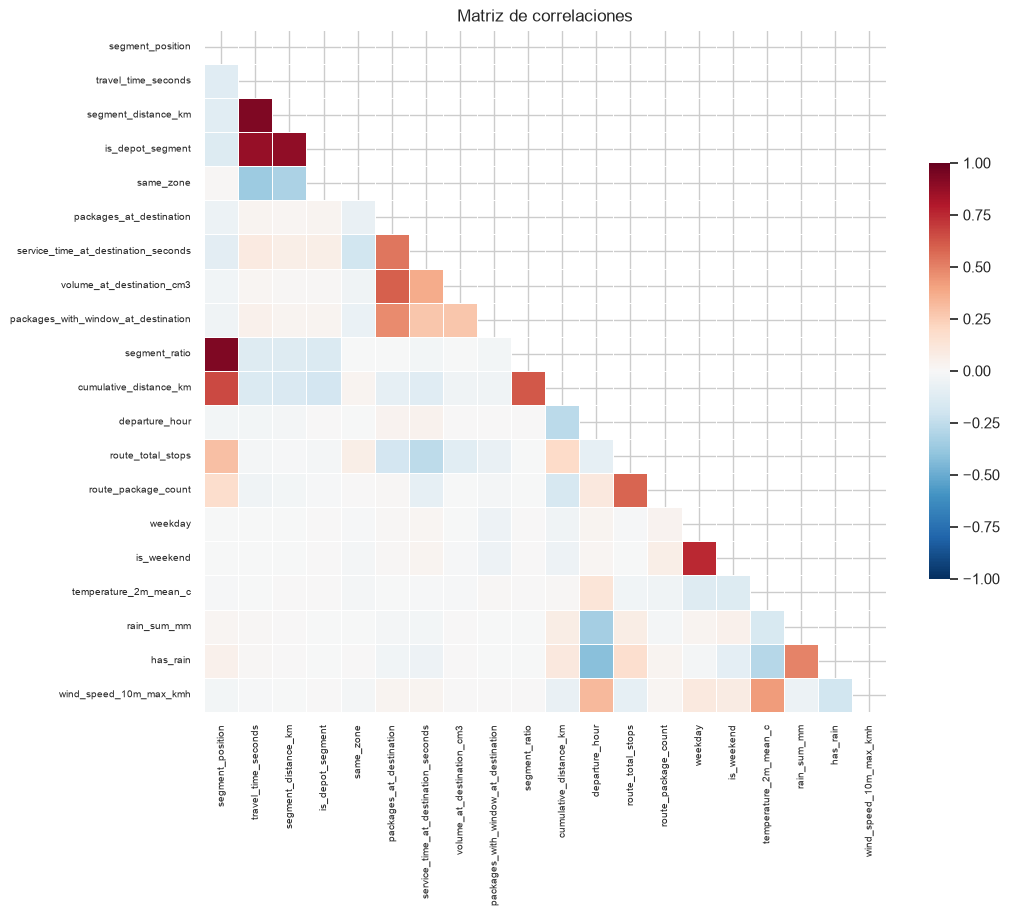

In [15]:
corr = tramos[numericas(tramos)].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.4, cbar_kws={"shrink": .6}, ax=ax)
ax.set_title("Matriz de correlaciones"); ax.tick_params(labelsize=7)
plt.show()

In [16]:
cols = numericas(tramos)
pares = [{"a": a, "b": b, "corr": round(corr.loc[a, b], 4)}
         for i, a in enumerate(cols) for b in cols[i+1:] if abs(corr.loc[a, b]) > 0.7]
pd.DataFrame(sorted(pares, key=lambda p: -abs(p["corr"])))

,a,b,corr
0,segment_position,segment_ratio,0.9370
1,travel_time_seconds,segment_distance_km,0.9350
2,segment_distance_km,is_depot_segment,0.8831
3,travel_time_seconds,is_depot_segment,0.8748
4,weekday,is_weekend,0.7563


Hay pares que llevan la misma informacion: `segment_position` y `segment_ratio` son la
posicion reescalada, y `weekday` con `is_weekend` es evidente. Meterlas juntas en un modelo
lineal introduce colinealidad sin aportar nada.

Como el objetivo esta muy sesgado, conviene mirar tambien la correlacion de Spearman, que es
por rangos y no asume linealidad.

In [17]:
con_obj = corr[OBJETIVO].drop(OBJETIVO).dropna()
con_obj = con_obj.reindex(con_obj.abs().sort_values(ascending=False).index)
m = tramos.sample(60000, random_state=42)
spearman = {c: stats.spearmanr(m[c], m[OBJETIVO]).statistic for c in con_obj.index[:10]}
pd.DataFrame({"pearson": con_obj.head(10).round(4),
              "spearman": pd.Series(spearman).round(4)})

,pearson,spearman
segment_distance_km,0.9350,0.7816
is_depot_segment,0.8748,0.1439
same_zone,-0.3603,NaN
cumulative_distance_km,-0.1476,0.0208
segment_ratio,-0.1253,-0.0284
segment_position,-0.1174,-0.0229
service_time_at_destination_seconds,0.0896,0.1034
packages_with_window_at_destination,0.0519,0.0904
route_package_count,-0.0440,-0.0757
packages_at_destination,0.0278,-0.0092


## 8. Distancia frente a tiempo

La distancia es la variable dominante, pero conviene mirarla por separado en cada poblacion.

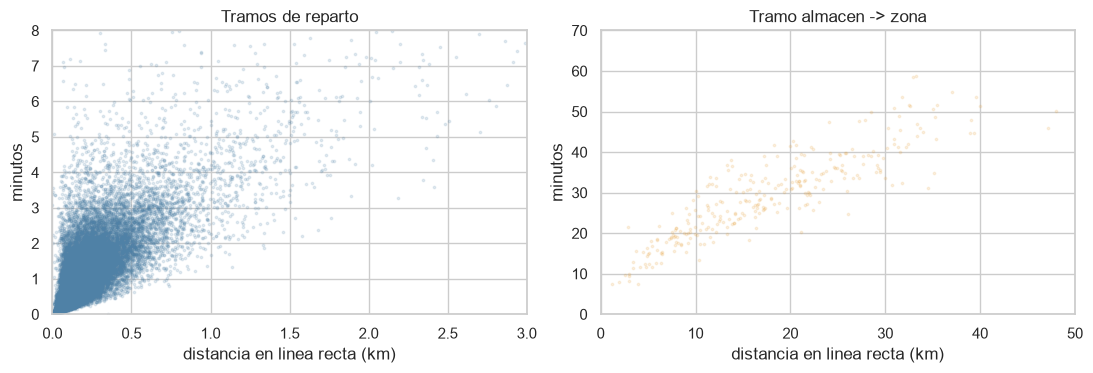

In [18]:
m = tramos.sample(40000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (t, sub, color, xl, yl) in zip(axes, [
        ("Tramos de reparto", m[m.is_depot_segment == 0], AZUL, (0, 3), (0, 8)),
        ("Tramo almacen -> zona", m[m.is_depot_segment == 1], NARANJA, (0, 50), (0, 70))]):
    ax.scatter(sub.segment_distance_km, sub[OBJETIVO] / 60, s=3, alpha=.15, color=color)
    ax.set_xlim(*xl); ax.set_ylim(*yl); ax.set_title(t)
    ax.set_xlabel("distancia en linea recta (km)"); ax.set_ylabel("minutos")
plt.tight_layout(); plt.show()

In [19]:
filas = []
for nombre, sub in [("todos", tramos), ("reparto", tramos[tramos.is_depot_segment == 0]),
                    ("almacen -> zona", tramos[tramos.is_depot_segment == 1])]:
    x, y = sub.segment_distance_km.values, sub[OBJETIVO].values
    a, b = np.polyfit(x, y, 1)
    filas.append({"poblacion": nombre, "correlacion": round(np.corrcoef(x, y)[0, 1], 3),
                  "R2_solo_distancia": round(r2(y, a * x + b), 3),
                  "velocidad_kmh": round(3600 * x.sum() / y.sum(), 1)})
pd.DataFrame(filas)

,poblacion,correlacion,R2_solo_distancia,velocidad_kmh
0,todos,0.935,0.874,15.4
1,reparto,0.764,0.584,11.4
2,almacen -> zona,0.870,0.757,35.3


**La correlacion global de 0,935 es enganosa**: procede en buena parte de que existen dos
grupos separados. Dentro del reparto baja a 0,764 y la distancia explica solo el 58% de la
variabilidad. Ese 42% restante es lo que el modelo tiene que aprender.

Las velocidades son en linea recta, no por carretera, asi que la real es mayor. Sirven para
comparar, no como medida absoluta.

## 9. Baselines de referencia

Antes de entrenar nada hay que saber contra que se compara.

In [20]:
x, y = tramos.segment_distance_km.values, tramos[OBJETIVO].values

r2_ingenuo = r2(y, x * (y.sum() / x.sum()))
a, b = np.polyfit(x, y, 1)
r2_recta = r2(y, a * x + b)

pred = np.zeros(len(tramos))
for ind in (0, 1):
    mask = (tramos.is_depot_segment == ind).values
    aa, bb = np.polyfit(x[mask], y[mask], 1)
    pred[mask] = aa * x[mask] + bb
r2_sep = r2(y, pred)

pd.DataFrame({"baseline": ["distancia / velocidad media", "una recta para todo", "una recta por poblacion"],
              "R2": [round(r2_ingenuo, 3), round(r2_recta, 3), round(r2_sep, 3)],
              "MAE_min": [None, None, round(np.abs(y - pred).mean() / 60, 3)]})

,baseline,R2,MAE_min
0,distancia / velocidad media,-1.034,NaN
1,una recta para todo,0.874,NaN
2,una recta por poblacion,0.919,0.447


**Sorpresa**: el baseline mas intuitivo, dividir la distancia entre una velocidad media, da
un R2 **negativo**, es decir peor que predecir siempre la media. La razon es la de la seccion 4:
una unica velocidad no puede describir dos poblaciones que circulan a 35 y a 11 km/h.

La referencia honesta a batir es la ultima: **R2 0,919 y 0,45 minutos de error medio**.

Dos aclaraciones importantes:

- **Estimar una velocidad media a partir del tiempo no es fuga de datos.** La regla es no usar el
  objetivo de una fila para predecir esa misma fila. Una media del conjunto es un parametro
  agregado, igual que la pendiente de una regresion. Lo prohibido seria dar al modelo la
  velocidad **de cada tramo** como variable, porque entonces velocidad y distancia reconstruyen
  el tiempo por division.
- Estas cifras se calculan sobre todos los datos, lo que vale para describir. Al modelar hay que
  reajustar el baseline **solo con el entrenamiento** y medirlo en la prueba.

## 10. Que explica lo que la distancia no explica

In [21]:
d = tramos[tramos.is_depot_segment == 0].copy()
x, y = d.segment_distance_km.values, d[OBJETIVO].values
a, b = np.polyfit(x, y, 1)
d["residuo"] = y - (a * x + b)

cand = [c for c in numericas(d) if c not in (OBJETIVO, "residuo", "is_depot_segment")]
res = pd.Series({c: d[c].astype(float).corr(d.residuo) for c in cand}).dropna()
res.reindex(res.abs().sort_values(ascending=False).index).head(10).round(4).to_frame("corr_con_residuo")

,corr_con_residuo
same_zone,-0.1877
service_time_at_destination_seconds,0.0840
packages_with_window_at_destination,0.0645
route_total_stops,-0.0637
cumulative_distance_km,-0.0472
packages_at_destination,0.0425
route_package_count,-0.0324
has_rain,-0.0294
segment_position,-0.0249
volume_at_destination_cm3,0.0210


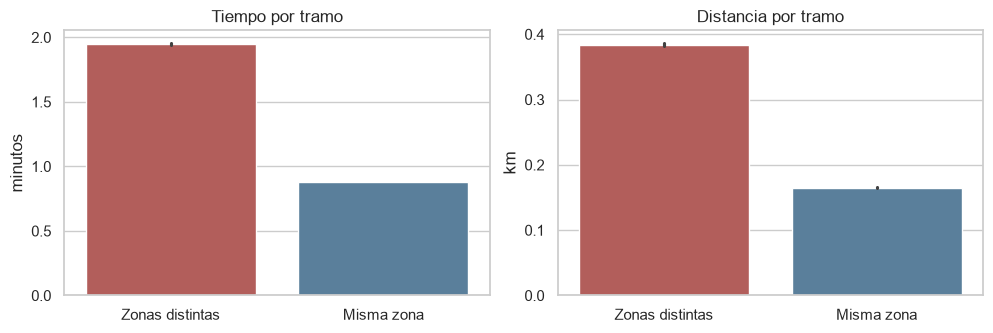

,tramos,minutos,km
same_zone,,,
0.0,119811,1.946,0.384
1.0,759904,0.878,0.165


In [22]:
sz = d.dropna(subset=["same_zone"])
etiq = sz.same_zone.map({0: "Zonas distintas", 1: "Misma zona"})
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
sns.barplot(x=etiq, y=sz[OBJETIVO] / 60, hue=etiq, palette=[ROJO, AZUL], legend=False, ax=axes[0])
axes[0].set_title("Tiempo por tramo"); axes[0].set_ylabel("minutos"); axes[0].set_xlabel("")
sns.barplot(x=etiq, y=sz.segment_distance_km, hue=etiq, palette=[ROJO, AZUL], legend=False, ax=axes[1])
axes[1].set_title("Distancia por tramo"); axes[1].set_ylabel("km"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

sz.groupby("same_zone").agg(tramos=(OBJETIVO, "size"),
                            minutos=(OBJETIVO, lambda s: round(s.mean() / 60, 3)),
                            km=("segment_distance_km", lambda s: round(s.mean(), 3)))

**`same_zone` es la mejor pista despues de la distancia.** Moverse dentro de la misma zona de
planificacion sale mas rapido de lo que la distancia haria pensar. Tiene sentido operativo: las
zonas agrupan calles proximas y bien conectadas, asi que saltar de una zona a otra penaliza
aunque la distancia en linea recta sea parecida.

## 11. Contexto: geografia, tiempo y clima

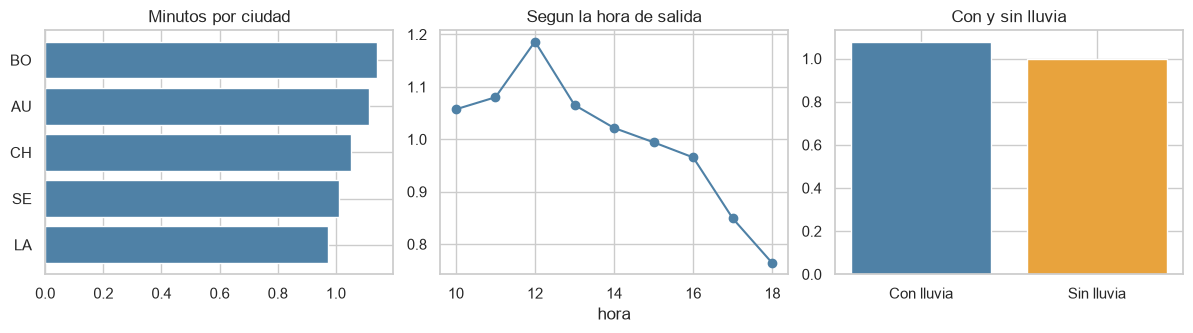

In [23]:
d = tramos[tramos.is_depot_segment == 0].copy()
d["ciudad"] = d.station_code.str[1:3]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
ciudad = d.groupby("ciudad")[OBJETIVO].mean().sort_values() / 60
axes[0].barh(ciudad.index, ciudad.values, color=AZUL); axes[0].set_title("Minutos por ciudad")
hora = d.groupby("departure_hour")[OBJETIVO].mean() / 60
axes[1].plot(hora.index, hora.values, marker="o", color=AZUL)
axes[1].set_title("Segun la hora de salida"); axes[1].set_xlabel("hora")
lluvia = d.assign(l=np.where(d.has_rain == 1, "Con lluvia", "Sin lluvia")).groupby("l")[OBJETIVO].mean() / 60
axes[2].bar(lluvia.index, lluvia.values, color=[AZUL, NARANJA]); axes[2].set_title("Con y sin lluvia")
plt.tight_layout(); plt.show()

Parece que con lluvia se tarda mas. **Pero hay que comprobarlo controlando por ciudad.**

In [24]:
global_corr = d.has_rain.astype(float).corr(d[OBJETIVO])
por_est = {e: s.has_rain.astype(float).corr(s[OBJETIVO])
           for e, s in d.groupby("station_code") if s.has_rain.nunique() > 1 and len(s) > 1000}

print(f"Correlacion lluvia-tiempo, global:            {global_corr:+.4f}")
print(f"Correlacion media dentro de cada estacion:    {np.mean(list(por_est.values())):+.4f}")
print()
pd.DataFrame({"% rutas con lluvia": d.groupby("ciudad").has_rain.mean().round(3) * 100,
              "minutos por tramo": (d.groupby("ciudad")[OBJETIVO].mean() / 60).round(3)}).sort_values("% rutas con lluvia")

Correlacion lluvia-tiempo, global:            +0.0369
Correlacion media dentro de cada estacion:    +0.0017



,% rutas con lluvia,minutos por tramo
ciudad,,
LA,5.6,0.972
SE,24.2,1.010
AU,48.2,1.114
CH,76.7,1.054
BO,76.9,1.141


**Paradoja de Simpson.** La correlacion global sugiere que la lluvia ralentiza el reparto,
pero desaparece al controlar por estacion. Las ciudades lluviosas del dataset son justo las que
tienen rutas mas largas, asi que la lluvia estaba haciendo de disfraz de la variable "ciudad".

Esto no es un detalle menor: si se entrena con meteorologia **sin incluir `station_code`**, el
modelo aprendera la relacion falsa y el agente acabara diciendo a un cliente que su paquete
llega tarde por la lluvia, cuando en realidad es por la ciudad en la que vive.

## 12. Contrastes estadisticos

Para no quedarse en la impresion visual. Se usan pruebas no parametricas porque la distribucion
dista mucho de la normal.

In [25]:
filas = []

u = stats.mannwhitneyu(tramos[tramos.is_depot_segment == 1][OBJETIVO], d[OBJETIVO])
filas.append({"comparacion": "deposito vs reparto", "prueba": "Mann-Whitney", "p": f"{u.pvalue:.3g}", "d_cohen": None})

con, sin = d[d.has_rain == 1][OBJETIVO], d[d.has_rain == 0][OBJETIVO]
u2 = stats.mannwhitneyu(con, sin)
dc = (con.mean() - sin.mean()) / np.sqrt((con.var() + sin.var()) / 2)
filas.append({"comparacion": "con lluvia vs sin lluvia", "prueba": "Mann-Whitney", "p": f"{u2.pvalue:.3g}", "d_cohen": round(dc, 4)})

a_, b_ = sz[sz.same_zone == 1][OBJETIVO], sz[sz.same_zone == 0][OBJETIVO]
u3 = stats.mannwhitneyu(a_, b_)
dz = (a_.mean() - b_.mean()) / np.sqrt((a_.var() + b_.var()) / 2)
filas.append({"comparacion": "misma zona vs distinta", "prueba": "Mann-Whitney", "p": f"{u3.pvalue:.3g}", "d_cohen": round(dz, 4)})

k = stats.kruskal(*[s[OBJETIVO].values for _, s in d.groupby("station_code") if len(s) > 500])
filas.append({"comparacion": "entre estaciones", "prueba": "Kruskal-Wallis", "p": f"{k.pvalue:.3g}", "d_cohen": None})

pd.DataFrame(filas)

,comparacion,prueba,p,d_cohen
0,deposito vs reparto,Mann-Whitney,0,NaN
1,con lluvia vs sin lluvia,Mann-Whitney,3.57e-289,0.0771
2,misma zona vs distinta,Mann-Whitney,0,-0.8403
3,entre estaciones,Kruskal-Wallis,0,NaN


**Ojo con interpretar las p.** Con 900.000 filas casi cualquier diferencia sale
significativa. El caso de la lluvia lo ilustra perfectamente: p practicamente cero, pero un
tamano del efecto (d de Cohen) por debajo de 0,1, que se considera **despreciable**.

Significativo no es lo mismo que importante. Por eso hay que mirar el tamano del efecto.

---

# Parte B: la tabla de rutas

Hasta aqui todo ha ido sobre los tramos, que es lo que alimenta el modelo. Esta parte describe
la tabla por ruta, que sirve para planificacion, contexto y analisis agregado.

## 13. Calidad y columnas equivalentes

In [26]:
print("Rutas:", len(rutas), "| columnas:", rutas.shape[1])
print("Celdas nulas:", rutas.isna().sum().sum())
print("Identificadores repetidos:", rutas.route_id.duplicated().sum())
print()
print("Columnas constantes:", [c for c in rutas.columns if rutas[c].nunique(dropna=False) <= 1])

Rutas: 6112 | columnas: 60
Celdas nulas: 0
Identificadores repetidos: 0

Columnas constantes: ['station_stops', 'other_scan_status_count', 'snowfall_sum_cm', 'year', 'is_us_public_holiday']


In [27]:
num_r = list(rutas.select_dtypes(include=[np.number]).columns)
cr = rutas[num_r].corr().abs()
equiv = [f"{a} == {b}" for i, a in enumerate(num_r) for b in num_r[i+1:] if cr.loc[a, b] > 0.9999]
equiv

['total_stops == dropoff_stops',
 'total_stops == stop_rows',
 'total_stops == sequence_stop_count',
 'total_stops == max_actual_sequence_position',
 'dropoff_stops == stop_rows',
 'dropoff_stops == sequence_stop_count',
 'dropoff_stops == max_actual_sequence_position',
 'stop_rows == sequence_stop_count',
 'stop_rows == max_actual_sequence_position',
 'mean_planned_service_time_seconds == planned_service_time_per_package_seconds',
 'mean_package_volume_cm3 == volume_per_package_cm3',
 'sequence_stop_count == max_actual_sequence_position',
 'route_duration_seconds == route_duration_hours',
 'precipitation_sum_mm == rain_sum_mm',
 'has_rain == has_precipitation']

Todas las variantes del numero de paradas son **la misma magnitud**: `total_stops` es
`dropoff_stops` mas la estacion, y las demas son recuentos equivalentes de la misma secuencia.
Hay que quedarse con una sola.

## 14. Como es una ruta tipica

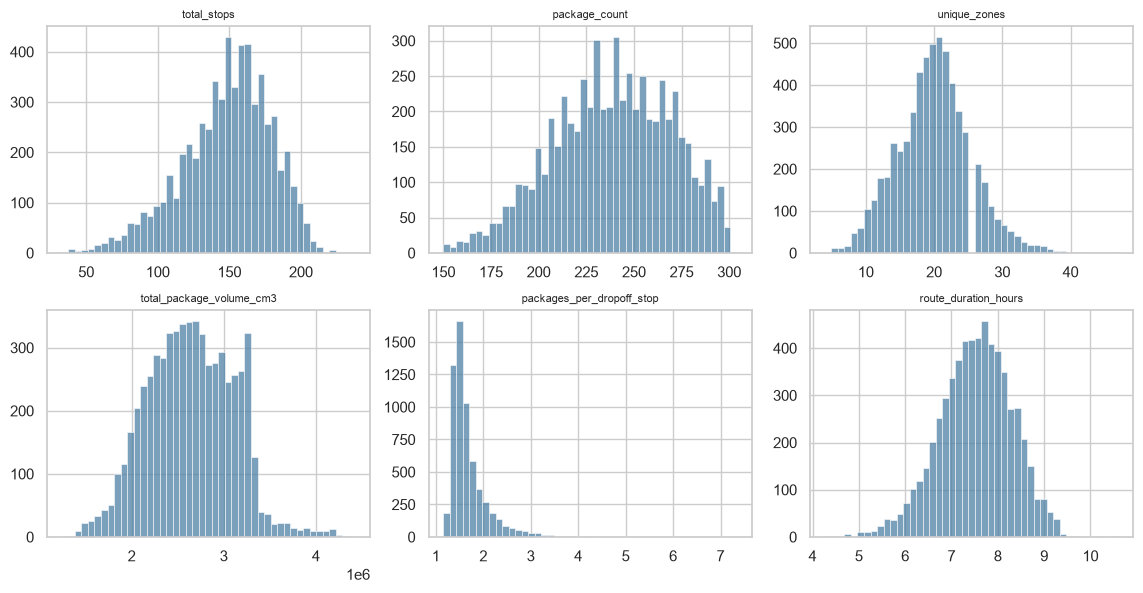

,mean,std,min,50%,max
total_stops,147.99,31.03,33.00,151.00,238.00
package_count,238.41,30.98,150.00,239.00,304.00
unique_zones,20.04,5.51,4.00,20.00,47.00
total_package_volume_cm3,2641162.73,470587.32,1242909.09,2635624.31,4427701.53
packages_per_dropoff_stop,1.69,0.43,1.16,1.56,7.34
route_duration_hours,7.51,0.78,4.27,7.55,10.60


In [28]:
cols = ["total_stops", "package_count", "unique_zones", "total_package_volume_cm3",
        "packages_per_dropoff_stop", "route_duration_hours"]
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6))
for ax, c in zip(axes.flat, cols):
    sns.histplot(rutas[c], bins=45, color=AZUL, ax=ax)
    ax.set_title(c, fontsize=8); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

rutas[cols].describe().T[["mean", "std", "min", "50%", "max"]].round(2)

## 15. Que determina la duracion de una ruta

In [29]:
excluir = {"route_duration_seconds", "route_duration_hours", "total_travel_time_seconds"}
num_r = [c for c in rutas.select_dtypes(include=[np.number]).columns if c not in excluir]
cd = rutas[num_r + ["route_duration_seconds"]].corr()["route_duration_seconds"].drop("route_duration_seconds").dropna()
cd.reindex(cd.abs().sort_values(ascending=False).index).head(10).round(4).to_frame("corr_con_duracion")

,corr_con_duracion
total_planned_service_time_seconds,0.6079
mean_planned_service_time_seconds,0.3948
planned_service_time_per_package_seconds,0.3948
total_stops,0.2940
dropoff_stops,0.2940
sequence_stop_count,0.2940
stop_rows,0.2940
max_actual_sequence_position,0.2940
delivery_haversine_distance_km,0.2846
invalid_sequence_score,0.2670


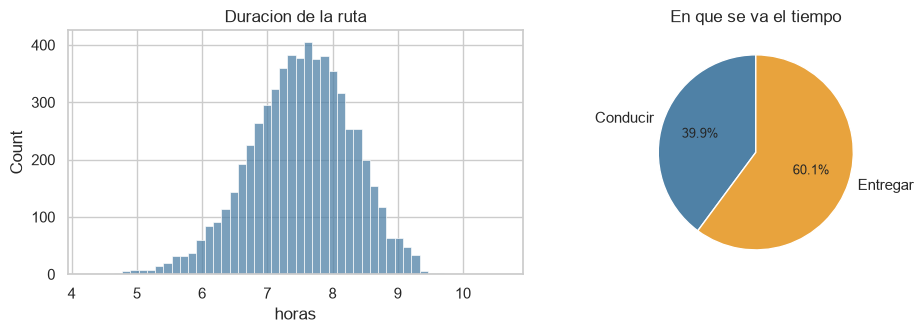

In [30]:
conducir = rutas.total_travel_time_seconds.sum()
entregar = rutas.total_planned_service_time_seconds.sum()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
sns.histplot(rutas.route_duration_hours, bins=50, color=AZUL, ax=axes[0])
axes[0].set_title("Duracion de la ruta"); axes[0].set_xlabel("horas")
axes[1].pie([conducir, entregar], labels=["Conducir", "Entregar"], autopct="%1.1f%%",
            colors=[AZUL, NARANJA], startangle=90)
axes[1].set_title("En que se va el tiempo")
plt.tight_layout(); plt.show()

El grueso de la jornada se va **entregando, no conduciendo**. Como el tiempo de servicio
viene planificado en el manifiesto y se conoce antes de salir, el modelo solo tiene que estimar
la parte de conducir.

Tambien conviene describir `route_score`, la etiqueta de calidad que Amazon asigno a cada ruta.
**Ya no es el objetivo del proyecto**, pero estaba en el planteamiento anterior.

In [31]:
score = rutas.route_score.value_counts()
pd.DataFrame({"rutas": score,
              "porcentaje": (score / len(rutas) * 100).round(2),
              "duracion_media_h": rutas.groupby("route_score").route_duration_hours.mean().round(2)})

,rutas,porcentaje,duracion_media_h
route_score,,,
High,2718,44.47,7.41
Low,102,1.67,7.81
Medium,3292,53.86,7.60


La clase minoritaria es solo el 1,67% de las rutas. Ese **desbalanceo severo** fue una de
las razones para cambiar de objetivo: obligaba a pelearse con metricas por clase y particiones
estratificadas, mientras que el tiempo de entrega es una variable continua y bien repartida.

---

## 16. Conclusiones para el modelado

**Sobre los datos**

1. El dataset esta limpio: sin duplicados y con los unicos nulos explicados (el almacen no tiene
   zona).
2. Cinco columnas de la tabla de rutas no varian nunca y hay que excluirlas.
3. Varias columnas miden la misma magnitud: hay que quedarse con una variable de tamano de ruta.
4. Los atipicos y los tramos de cero segundos son casos reales, no errores. **No recortarlos.**

**Sobre el problema**

5. **El objetivo son dos poblaciones**: incluir `is_depot_segment` o entrenar por separado.
6. **El baseline a batir es R2 0,919 y MAE 0,45 minutos**, reajustado sobre el entrenamiento.
   Presentar cualquier metrica comparada con el, nunca en absoluto.
7. **La distancia explica el 58%** del tiempo de reparto; el resto es el trabajo del modelo.
8. **`same_zone` es la mejor senal** despues de la distancia.
9. **El clima no aporta y ademas engana.** Si se usa, incluir `station_code`.

**Como entrenar**

10. **Particion `GroupKFold` por `route_id`**: los tramos de una ruta no son independientes.
11. **Metrica MAE en minutos**, que se explica sola ante un tribunal o un cliente.
12. **Priorizar arboles** (LightGBM, CatBoost): toleran la asimetria, manejan la alta cardinalidad
    de las zonas y permiten explicar cada prediccion con TreeSHAP, que es lo que necesita el
    agente para decir *por que* un paquete llega a esa hora.